### Inciso 7 predicciones y pruebas reales

In [50]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

model_path = 'modelos/cnn_deep.pt'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Modelo 2: CNN más profunda con BN + Dropout ===
class CNN_Deep(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True)
            )
        self.features = nn.Sequential(
            block(3, 32), block(32, 32), nn.MaxPool2d(2),    
            block(32, 64), block(64, 64), nn.MaxPool2d(2),   
            block(64,128),                                   
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)
    
# Cargar el modelo
model = CNN_Deep().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
    

CNN_Deep(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=T

### Paso 2: Cargar y transformar imágenes manuscritas

En esta sección se cargarán imágenes desde el directorio `imagenes_mano/`, se transformarán al formato del modelo (3 canales RGB, tamaño 28x28, normalización) y se preparan.


In [51]:
from PIL import ImageOps
import numpy as np
from scipy.ndimage import center_of_mass

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Función para centrar el dígito en el lienzo
def centrar_imagen(imagen_np):
    if imagen_np.max() == 0:
        return imagen_np  # Imagen completamente negra, sin nada que centrar

    com = center_of_mass(imagen_np > 0)
    cy, cx = int(com[0]), int(com[1])

    coords = np.argwhere(imagen_np)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    recorte = imagen_np[y0:y1, x0:x1]

    h, w = recorte.shape
    tamaño = 28
    lienzo = np.zeros((tamaño, tamaño), dtype=np.uint8)

    start_y = max((tamaño - h) // 2, 0)
    start_x = max((tamaño - w) // 2, 0)

    lienzo[start_y:start_y + h, start_x:start_x + w] = recorte
    return lienzo

def cargar_imagenes_mano_preprocesadas(directorio):
    imagenes = []
    nombres = []

    for nombre_archivo in os.listdir(directorio):
        if nombre_archivo.lower().endswith(('.png', '.jpg', '.jpeg')):
            ruta = os.path.join(directorio, nombre_archivo)

            # Abrir imagen, convertir a escala de grises
            imagen = Image.open(ruta).convert('L')

            # Invertir: pasa fondo blanco a negro y dígito oscuro a blanco
            imagen = ImageOps.invert(imagen)

            # Convertir a numpy array para aplicar umbral
            imagen_np = np.array(imagen)
            imagen_np = (imagen_np > 100) * 255

            # Centrar el dígito en el lienzo
            imagen_np = centrar_imagen(imagen_np)

            # Volver a PIL y convertir a RGB para el modelo
            imagen = Image.fromarray(imagen_np.astype(np.uint8)).convert('RGB')

            # Aplicar transformaciones (resize, tensor, normalize)
            imagen_tensor = transform(imagen).unsqueeze(0).to(device)
            imagenes.append(imagen_tensor)
            nombres.append(nombre_archivo)

    return imagenes, nombres

# Cargar imágenes preprocesadas
imagenes_mano, nombres_imagenes = cargar_imagenes_mano_preprocesadas('imagenes_mano')
print(f"Se cargaron y preprocesaron {len(imagenes_mano)} imágenes manuscritas.")


Se cargaron y preprocesaron 30 imágenes manuscritas.


### Paso 3: Realizar predicciones con el modelo `CNN_Deep`

En este paso se realizará la inferencia sobre cada imagen manuscrita cargada.

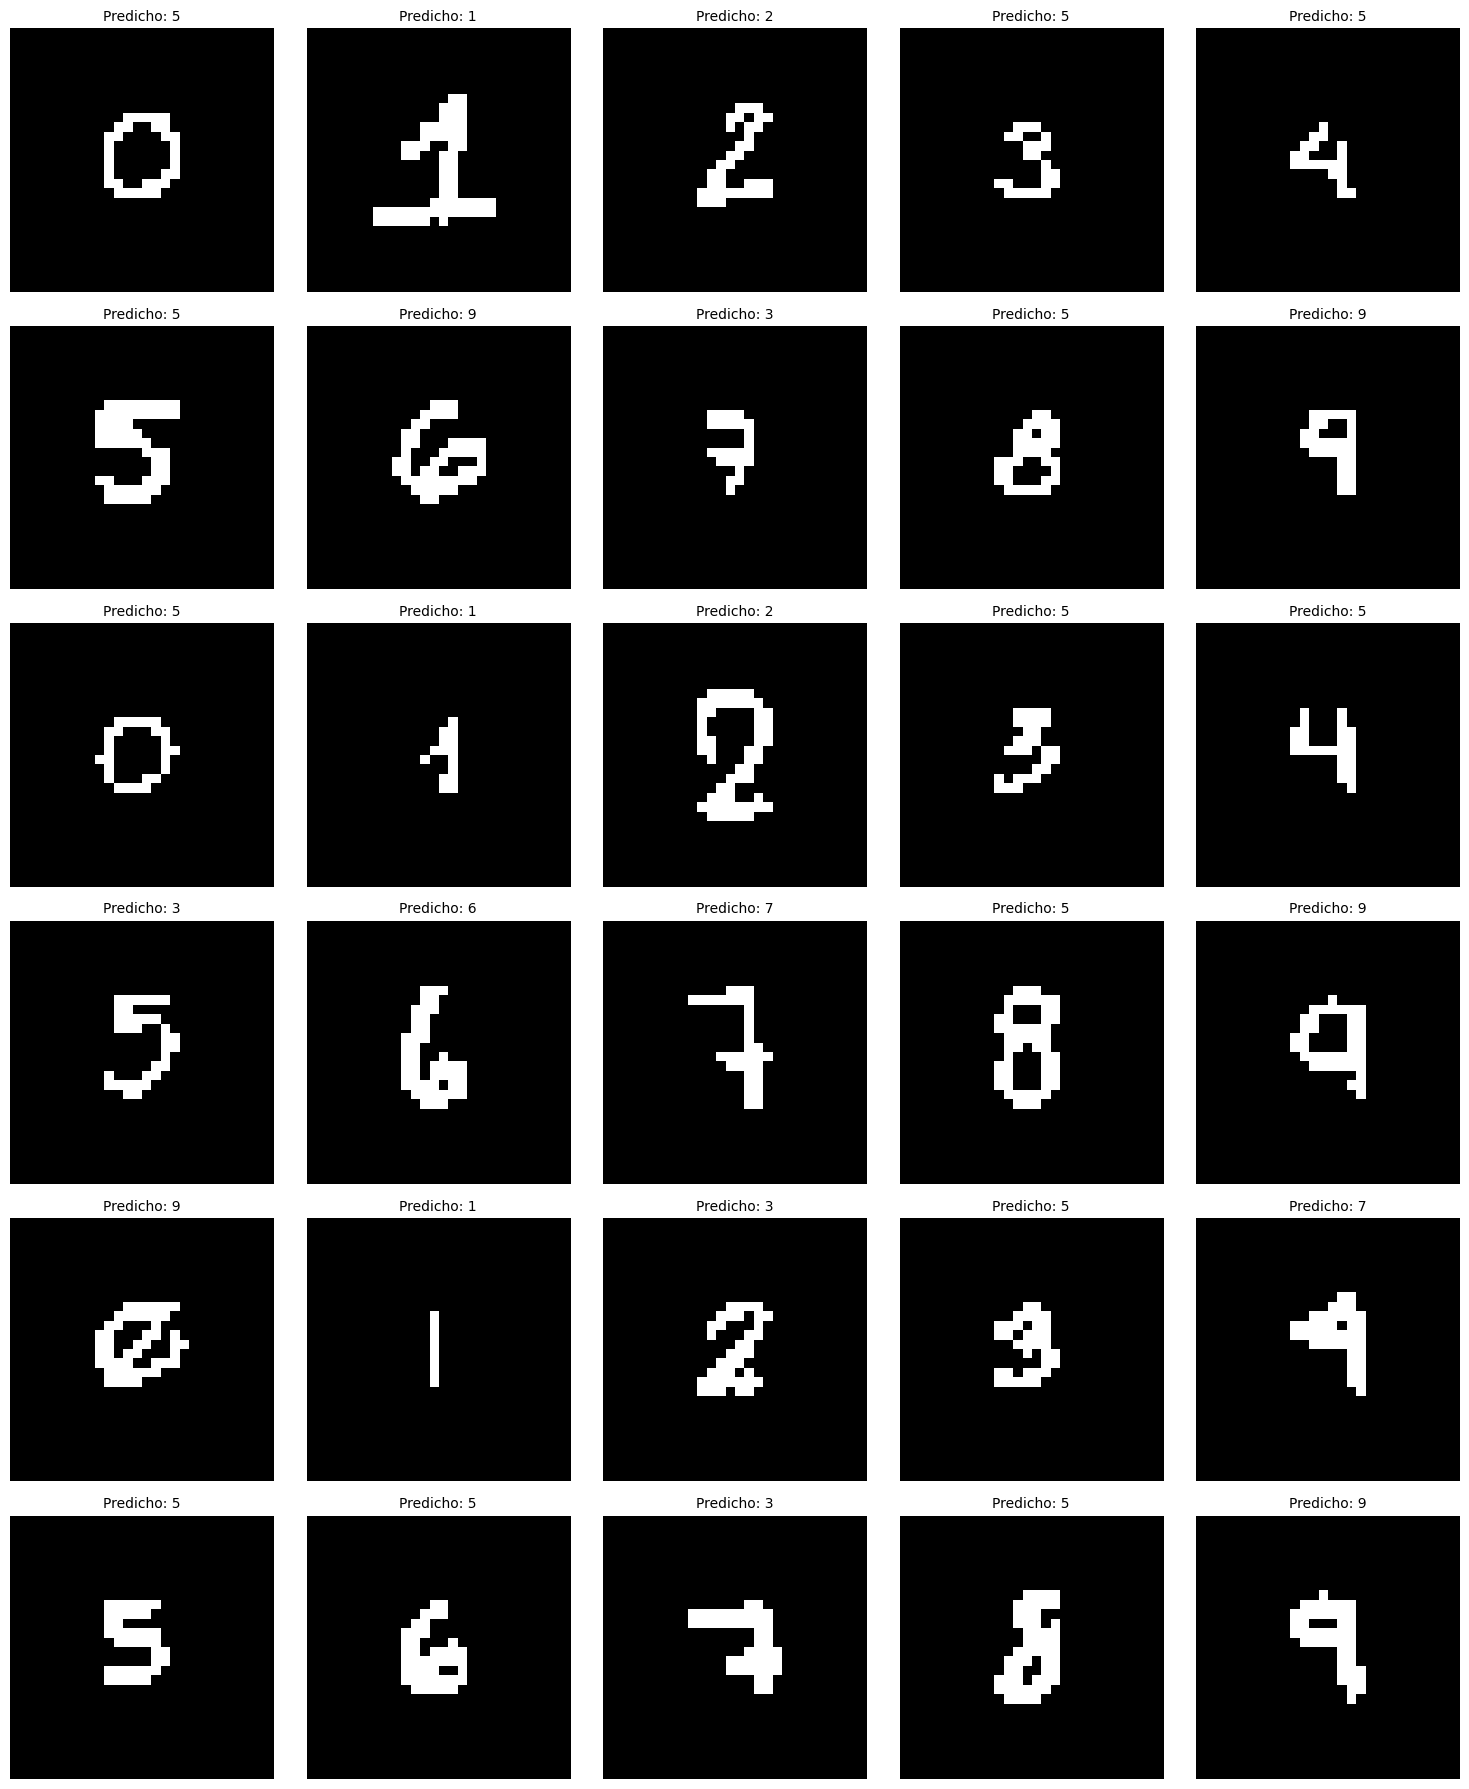

In [52]:
por_fila = 5
filas = (len(imagenes_mano) + por_fila - 1) // por_fila

plt.figure(figsize=(15, 3 * filas))

for idx, (imagen_tensor, nombre) in enumerate(zip(imagenes_mano, nombres_imagenes)):
    with torch.no_grad():
        salida = model(imagen_tensor)
        prediccion = torch.argmax(salida, dim=1).item()

    imagen_np = imagen_tensor.squeeze().cpu().numpy() 

    if imagen_np.ndim == 3:
        imagen_np = imagen_np.mean(axis=0) 

    imagen_np = (imagen_np * 0.5 + 0.5) * 255 
    imagen_np = imagen_np.astype(np.uint8)

    plt.subplot(filas, por_fila, idx + 1)
    plt.imshow(imagen_np, cmap='gray')
    plt.title(f"Predicho: {prediccion}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [53]:
etiquetas_reales = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                    0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
                    0, 1, 2, 3, 4, 5, 6, 7, 8, 9]  

# Recalcular predicciones y compararlas
predicciones = []
for imagen_tensor in imagenes_mano:
    with torch.no_grad():
        salida = model(imagen_tensor)
        prediccion = torch.argmax(salida, dim=1).item()
        predicciones.append(prediccion)

# Calcular accuracy
aciertos = sum([pred == real for pred, real in zip(predicciones, etiquetas_reales)])
accuracy = aciertos / len(etiquetas_reales) * 100

print(f"Accuracy en imágenes manuscritas: {accuracy:.2f}%")


Accuracy en imágenes manuscritas: 40.00%


### Paso 6: Resultados y análisis del modelo con imágenes manuscritas

Después de realizar varios pasos para mejorar las imágenes escritas a mano, se probó el modelo `CNN_Deep` con un conjunto de 30 imágenes generadas por los integrantes del grupo. El resultado fue un **accuracy del 40%**, lo cual indica que el modelo logró acertar 12 de las 30 imágenes.

#### ¿Qué pudo afectar los resultados?

Aunque se mejoró bastante en comparación con el primer intento (donde se obtuvo un 23.33%), todavía hay varios factores que pudieron afectar el desempeño del modelo:

- **Diferencia en el estilo de los datos:** El modelo fue entrenado con imágenes muy específicas (como las del dataset MNIST), que tienen fondo negro, dígitos blancos y bien centrados. Nuestras imágenes escritas a mano eran más variadas en forma, tamaño, grosor y en algunos casos con bordes, sombras o ruido de fondo.

- **Problemas de centrado y forma:** Aunque se aplicaron correcciones automáticas, algunas imágenes seguían estando desalineadas o con trazos irregulares. Esto hace más difícil que el modelo las reconozca correctamente.

- **Errores frecuentes hacia ciertos números:** En varias ocasiones el modelo dio como resultado el número 5, incluso cuando no era el correcto. Esto puede indicar que el modelo tiene una cierta inclinación o está más acostumbrado a reconocer ese tipo de forma por la forma en que fue entrenado.

#### ¿Qué se hizo para mejorar?

Se aplicaron varias transformaciones a las imágenes para que se parecieran más a las que el modelo está acostumbrado a ver:

- Se cambió el fondo blanco por negro y se invirtieron los colores.
- Se eliminaron sombras y bordes innecesarios.
- Se centraron los números automáticamente.
- Se aplicó un filtro que ayudó a cerrar trazos que estaban rotos.

Estas acciones permitieron que el modelo tuviera una mejor oportunidad de reconocer correctamente los números.

#### Conclusión

Aunque el modelo logró mejorar su rendimiento con estos ajustes, el resultado sigue mostrando que necesita imágenes más parecidas a las que fue entrenado para obtener buenos resultados. Este ejercicio demuestra la importancia de preparar bien los datos antes de usarlos, especialmente cuando se trabaja con modelos que ya fueron entrenados con otro tipo de imágenes.

Para mejorar aún más, se podría usar más ejemplos escritos a mano y aplicar variaciones en forma, tamaño y posición para entrenar o ajustar mejor el modelo.



In [ ]:
from PIL import Image, ImageDraw, ImageFont
import os
import random

def crear_digito_digital(numero, nombre_archivo, carpeta_salida="imagenes_mano1"):
    os.makedirs(carpeta_salida, exist_ok=True)
    ruta_guardado = os.path.join(carpeta_salida, nombre_archivo)

    # Crear imagen negra
    img = Image.new('L', (100, 100), color=0)
    draw = ImageDraw.Draw(img)

    # Cargar fuente
    try:
        font = ImageFont.truetype("arial.ttf", 80)
    except:
        from matplotlib import font_manager
        font_path = font_manager.findfont("DejaVu Sans")
        font = ImageFont.truetype(font_path, 80)

    # Variar posición ligeramente (opcional)
    offset_x = random.randint(20, 30)
    offset_y = random.randint(0, 10)

    # Dibujar número
    draw.text((offset_x, offset_y), str(numero), fill=255, font=font)

    # Redimensionar a 28x28
    img = img.resize((28, 28), resample=Image.Resampling.LANCZOS)

    # Guardar imagen
    img.save(ruta_guardado)

# Generar 10 muestras por dígito (0 al 9)
for digito in range(10):
    for muestra in range(10):
        nombre = f"{digito}_digital_{muestra}.png"
        crear_digito_digital(digito, nombre, carpeta_salida="imagenes_mano1")


### Se implemento esta funcion para hacer las pruebas y en efecto con esta funcion el reslutado era de 100% accuracy sugieriendo el que eran los numeros que no estaban del todo correctos y bien dibujados. y alineados pero asimismo podria mejorar aprendiendo de mas "caligrafia"